In [24]:
from readlif.reader import LifFile
import numpy as np
import matplotlib.pyplot as plt
from ipywidgets import interact

## Function Definitions

In [14]:
def import_lif_file(path):
    return (LifFile(path))

In [16]:
def calc_stack(file, idx_sample, idx_background):
    bg_container = file.get_image(idx_background)
    sample_container = file.get_image(idx_sample)
    sample = np.asarray([np.asarray(i) for i in sample_container.get_iter_z(t=0, c=0)])
    background = np.asarray([np.asarray(i) for i in bg_container.get_iter_z(t=0, c=0)])
    stack=sample/background
    return stack, sample, background

In [33]:
def calc_divergence(gx,gy):
    return (np.gradient(gx)[0] + np.gradient(gy)[1])

In [72]:
def calc_derivative(stack, idx_focused_image, idx_axial_separation):
    axial_step= 1e-6 

    n1 = idx_focused_image - idx_axial_separation
    n2 = idx_focused_image + idx_axial_separation 

    dz = np.abs(n2-n1) * axial_step    
    rows = slice(0,stack.shape[1])
    cols = slice(0, stack.shape[2])

    row_shift = 1
    col_shift = 0
    # I0 = np.roll(np.roll(np.fft.ifftshift(stack[n1][rows, cols]), row_shift, axis=0), col_shift, axis = 1)
    I0=np.fft.ifftshift(stack[n1][rows, cols])
    I1 = np.fft.ifftshift(stack[n2][rows, cols])
    Nx,Ny = I0.shape    

    dI = -(I0 - I1)/dz #axial intensity gradient estimate
    return Nx, Ny, dI, I0

In [62]:
def calculate_opl_fft(stack, idx_focused_image, idx_axial_separation): 
    pixel_size = 104e-9
    Nx, Ny, dI, I0=calc_derivative(stack, idx_focused_image, idx_axial_separation)


    kx = 2*np.pi*np.fft.fftfreq(Nx, pixel_size)
    ky = 2*np.pi*np.fft.fftfreq(Ny, pixel_size)
    Kx, Ky = np.meshgrid(ky,kx)

    eps = 1e-4 #to avoid division by zero
    F_Psi = np.fft.fft2(dI)/(-(Kx**2 + Ky**2) - eps)
    Psi = np.real(np.fft.ifft2(F_Psi))
    gx, gy = np.gradient(Psi)
    tmp = calc_divergence((gx/I0), (gy/I0))/pixel_size**2  #divide by ux**2 to account for the units!
    
    #solving the laplace equation via fft:
    F_OPL = np.fft.fft2(tmp)/(-(Kx**2 + Ky**2) - eps)
    OPL = np.real(np.fft.ifft2(F_OPL))
    OPL -= np.min(OPL)
    OPL= np.fft.ifftshift(OPL)*1e9
    return OPL

In [63]:
idx_sample=1
idx_background=3

In [64]:
def check_z_position_images(images):
    n = len(images)
    def view_image(i):
        plt.imshow(images[i], cmap=plt.cm.gray, interpolation='nearest')
        plt.title('Image Nr: %i' %i)
        plt.show()
    interact(view_image, i=(0,n-1))

In [65]:
def selector(stack, x1, x2, y1, y2):
    return stack[:,y1:y2,x1:x2].copy()

# Main

In [75]:
path=r"C:\Users\flori\Desktop\Testdaten\04_ctrl.lif"

In [76]:
file=import_lif_file(path)

for idx, entry in enumerate(file.image_list):
                print(idx, entry['name'], entry['dims'])

0 cells004 001/Series001_EnvironmentalGraph Dims(x=1, y=1, z=1, t=4, m=1)
1 cells004 001/Series001 Dims(x=2048, y=2048, z=11, t=1, m=1)
2 bg04 001/Series002_EnvironmentalGraph Dims(x=1, y=1, z=1, t=3, m=1)
3 bg04 001/Series002 Dims(x=2048, y=2048, z=11, t=1, m=1)


In [77]:
stack, sample, background = calc_stack(file, 1, 3)

In [81]:
%matplotlib inline
check_z_position_images(sample)
focused_image=6

interactive(children=(IntSlider(value=5, description='i', max=10), Output()), _dom_classes=('widget-interact',…

In [89]:
selected_stack=selector(stack, 800,1250,870,1250)

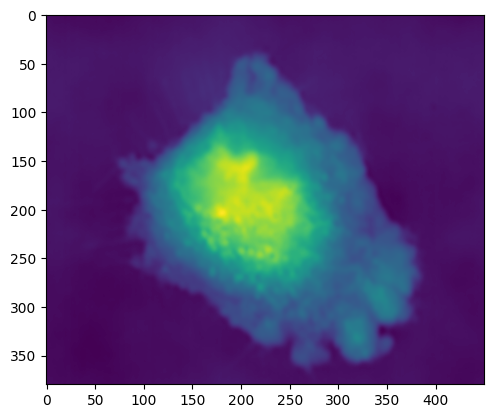

In [90]:
opd=calculate_opl_fft(selected_stack, focused_image, 1)
plt.imshow(opd, 'viridis')